# K-Means K=5 versus GMM C5 Spherical  
## Technical validation, assignment agreement and confidence comparison

### Purpose

This notebook compares the two frozen five-group customer-segmentation
solutions:

- **K-Means K=5**
- **Gaussian Mixture Model C5 with spherical covariance**

Both models use the same:

- 4,338 customers;
- seven processed behavioural features;
- CustomerID population;
- original-scale customer features.

The notebook compares:

1. common internal validation;
2. random-seed stability;
3. repeated 80% subsampling stability;
4. minimum group-size feasibility;
5. agreement between customer assignments;
6. aligned customer movement between models;
7. K-Means boundary evidence versus GMM membership uncertainty;
8. individual Silhouette agreement;
9. dashboard-ready customer-level comparison data.



## Important comparison rules

### Common metrics can be compared directly

The following are calculated on the same processed customer matrix:

- Silhouette Score;
- Davies–Bouldin Index;
- Calinski–Harabasz Index;
- random-seed ARI;
- subsampling ARI;
- smallest group percentage.

### Model-specific metrics cannot be directly compared

- K-Means WCSS belongs to K-Means.
- GMM AIC and BIC belong to GMM.

These model-specific objectives are reported for completeness but are not
placed on a common numerical scale.

### Customer-confidence rates are not identical measures

K-Means confidence uses Silhouette and centroid-distance margin.

GMM confidence uses posterior probability, probability margin and entropy.

The percentages can be compared descriptively, but one should not be treated
as the direct equivalent of the other.

## 1. Import libraries

In [ ]:
import os
import json
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    cohen_kappa_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 400)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure input archives and output folders

Upload these three ZIP files to Colab:

1. `KMeans_K5_Frozen_Baseline_v1.zip`
2. `Final_GMM_C5_Spherical_vs_Diagonal_Results.zip`
3. `GMM_C5_Membership_Probability_Results.zip`

The notebook reads frozen outputs only. It does not retrain either model.

In [ ]:
KMEANS_FROZEN_ZIP = (
    "/content/KMeans_K5_Frozen_Baseline_v1.zip"
)

GMM_FINAL_SELECTION_ZIP = (
    "/content/"
    "Final_GMM_C5_Spherical_vs_Diagonal_Results.zip"
)

GMM_MEMBERSHIP_ZIP = (
    "/content/"
    "GMM_C5_Membership_Probability_Results.zip"
)

EXTRACT_ROOT = Path(
    "/content/Frozen_Model_Comparison_Source"
)

KMEANS_EXTRACT_DIR = (
    EXTRACT_ROOT / "KMeans"
)

GMM_FINAL_EXTRACT_DIR = (
    EXTRACT_ROOT / "GMM_Final"
)

GMM_MEMBERSHIP_EXTRACT_DIR = (
    EXTRACT_ROOT / "GMM_Membership"
)

RESULTS_DIR = Path(
    "/content/"
    "KMeans_K5_vs_GMM_C5_Comparison_Results"
)

TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
DATASETS_DIR = RESULTS_DIR / "Datasets"
QUALITY_DIR = RESULTS_DIR / "Quality_Checks"
ALIGNMENT_DIR = RESULTS_DIR / "Alignment"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    DATASETS_DIR,
    QUALITY_DIR,
    ALIGNMENT_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

EXPECTED_CUSTOMERS = 4338
EXPECTED_GROUPS = 5

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

print("Comparison output folder:", RESULTS_DIR)

Comparison output folder: /content/KMeans_K5_vs_GMM_C5_Comparison_Results


## 3. Extract the frozen model archives

In [ ]:
required_archives = [
    KMEANS_FROZEN_ZIP,
    GMM_FINAL_SELECTION_ZIP,
    GMM_MEMBERSHIP_ZIP
]

missing_archives = [
    archive
    for archive in required_archives
    if not os.path.exists(archive)
]

if missing_archives:
    raise FileNotFoundError(
        "Missing required comparison archives:\n"
        + "\n".join(
            missing_archives
        )
    )

if EXTRACT_ROOT.exists():
    shutil.rmtree(
        EXTRACT_ROOT
    )

for folder in [
    KMEANS_EXTRACT_DIR,
    GMM_FINAL_EXTRACT_DIR,
    GMM_MEMBERSHIP_EXTRACT_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

with zipfile.ZipFile(
    KMEANS_FROZEN_ZIP
) as archive:
    archive.extractall(
        KMEANS_EXTRACT_DIR
    )

with zipfile.ZipFile(
    GMM_FINAL_SELECTION_ZIP
) as archive:
    archive.extractall(
        GMM_FINAL_EXTRACT_DIR
    )

with zipfile.ZipFile(
    GMM_MEMBERSHIP_ZIP
) as archive:
    archive.extractall(
        GMM_MEMBERSHIP_EXTRACT_DIR
    )

print("All frozen archives extracted successfully.")

All frozen archives extracted successfully.


## 4. Locate required frozen outputs

In [ ]:
def find_unique_file(
    search_root,
    file_name
):
    matches = list(
        Path(search_root).rglob(
            file_name
        )
    )

    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one '{file_name}' under "
            f"{search_root}, but found {len(matches)}."
        )

    return matches[0]


KMEANS_METRICS_FILE = find_unique_file(
    KMEANS_EXTRACT_DIR,
    "KMeans_K5_Frozen_Baseline_Metrics.csv"
)

KMEANS_CUSTOMERS_FILE = find_unique_file(
    KMEANS_EXTRACT_DIR,
    "customer_cluster_assignment_confidence.csv"
)

KMEANS_CLUSTER_SIZES_FILE = find_unique_file(
    KMEANS_EXTRACT_DIR,
    "KMeans_K5_Frozen_Cluster_Sizes.csv"
)

KMEANS_CONFIDENCE_SUMMARY_FILE = find_unique_file(
    KMEANS_EXTRACT_DIR,
    "KMeans_K5_Frozen_Confidence_Categories.csv"
)

GMM_SELECTED_EVIDENCE_FILE = find_unique_file(
    GMM_FINAL_EXTRACT_DIR,
    "final_gmm_c5_selected_evidence.csv"
)

GMM_COMPONENT_SIZES_FILE = find_unique_file(
    GMM_FINAL_EXTRACT_DIR,
    "final_gmm_c5_component_sizes.csv"
)

GMM_MEMBERSHIP_DATA_FILE = find_unique_file(
    GMM_MEMBERSHIP_EXTRACT_DIR,
    "final_gmm_customer_membership_analysis.csv"
)

GMM_CONFIDENCE_SUMMARY_FILE = find_unique_file(
    GMM_MEMBERSHIP_EXTRACT_DIR,
    "gmm_membership_confidence_summary.csv"
)

GMM_CONDITION_SUMMARY_FILE = find_unique_file(
    GMM_MEMBERSHIP_EXTRACT_DIR,
    "gmm_membership_condition_summary.csv"
)

located_files = pd.DataFrame({
    "Required_Output": [
        "K-Means frozen metrics",
        "K-Means customer assignments",
        "K-Means cluster sizes",
        "K-Means confidence summary",
        "GMM selected technical evidence",
        "GMM component sizes",
        "GMM customer membership data",
        "GMM confidence summary",
        "GMM condition summary"
    ],
    "File_Path": [
        KMEANS_METRICS_FILE,
        KMEANS_CUSTOMERS_FILE,
        KMEANS_CLUSTER_SIZES_FILE,
        KMEANS_CONFIDENCE_SUMMARY_FILE,
        GMM_SELECTED_EVIDENCE_FILE,
        GMM_COMPONENT_SIZES_FILE,
        GMM_MEMBERSHIP_DATA_FILE,
        GMM_CONFIDENCE_SUMMARY_FILE,
        GMM_CONDITION_SUMMARY_FILE
    ]
})

display(located_files)

,Required_Output,File_Path
0,K-Means frozen metrics,/content/Frozen_Model_Comparison_Source/KMeans...
1,K-Means customer assignments,/content/Frozen_Model_Comparison_Source/KMeans...
2,K-Means cluster sizes,/content/Frozen_Model_Comparison_Source/KMeans...
3,K-Means confidence summary,/content/Frozen_Model_Comparison_Source/KMeans...
4,GMM selected technical evidence,/content/Frozen_Model_Comparison_Source/GMM_Fi...
5,GMM component sizes,/content/Frozen_Model_Comparison_Source/GMM_Fi...
6,GMM customer membership data,/content/Frozen_Model_Comparison_Source/GMM_Me...
7,GMM confidence summary,/content/Frozen_Model_Comparison_Source/GMM_Me...
8,GMM condition summary,/content/Frozen_Model_Comparison_Source/GMM_Me...


## 5. Load the frozen K-Means and GMM outputs

In [ ]:
kmeans_metrics = pd.read_csv(
    KMEANS_METRICS_FILE
)

kmeans_customers = pd.read_csv(
    KMEANS_CUSTOMERS_FILE
)

kmeans_cluster_sizes = pd.read_csv(
    KMEANS_CLUSTER_SIZES_FILE
)

kmeans_confidence_summary = pd.read_csv(
    KMEANS_CONFIDENCE_SUMMARY_FILE
)

gmm_selected_evidence = pd.read_csv(
    GMM_SELECTED_EVIDENCE_FILE
)

gmm_component_sizes = pd.read_csv(
    GMM_COMPONENT_SIZES_FILE
)

gmm_membership_data = pd.read_csv(
    GMM_MEMBERSHIP_DATA_FILE
)

gmm_confidence_summary = pd.read_csv(
    GMM_CONFIDENCE_SUMMARY_FILE
)

gmm_condition_summary = pd.read_csv(
    GMM_CONDITION_SUMMARY_FILE
)

print("K-Means customer rows:", len(kmeans_customers))
print("GMM customer rows:", len(gmm_membership_data))

display(kmeans_metrics)
display(gmm_selected_evidence)

K-Means customer rows: 4338
GMM customer rows: 4338


,Model,Configuration,Customers,Features,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,WCSS_Inertia,Mean_Random_Seed_ARI,Minimum_Random_Seed_ARI,Mean_Subsampling_ARI,Minimum_Subsampling_ARI,Negative_Silhouette_Customers,Negative_Silhouette_Percentage,Low_Centroid_Margin_Customers,Low_Centroid_Margin_Percentage,Combined_Boundary_Customers,Combined_Boundary_Percentage,Smallest_Cluster_Percentage
0,K-Means,K=5,4338,7,0.2512,1.2230,"1,755.9685","6,866.0351",0.9999,0.9996,0.9541,0.9011,205,4.7257,501,11.5491,541,12.4712,11.9900


,Configuration,N_Components,Covariance_Type,Converged,Iterations,Fit_Time_Seconds,Average_Log_Likelihood,Lower_Bound,AIC,BIC,Silhouette_Score,Negative_Silhouette_Count,Negative_Silhouette_Percentage,Davies_Bouldin_Index,Calinski_Harabasz_Index,Smallest_Component_Count,Smallest_Component_Percentage,Largest_Component_Percentage,All_Components_At_Least_5_Percent,Minimum_Covariance_Value,Mean_Maximum_Probability,Median_Maximum_Probability,Low_Maximum_Probability_Count,Low_Maximum_Probability_Percentage,Mean_Probability_Margin,Median_Probability_Margin,Low_Probability_Margin_Count,Low_Probability_Margin_Percentage,Mean_Normalised_Entropy,Median_Normalised_Entropy,Requested_Runs_Seed,Successful_Runs_Seed,Convergence_Rate_Seed,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Mean_AIC_Across_Seeds,Mean_BIC_Across_Seeds,Requested_Runs_Subsample,Successful_Runs_Subsample,Sample_Size,Sample_Fraction,Convergence_Rate_Subsample,Mean_Subsampling_ARI,Median_Subsampling_ARI,Minimum_Subsampling_ARI,Maximum_Subsampling_ARI,Subsampling_ARI_Standard_Deviation,Mean_Smallest_Sample_Component_Percentage,Minimum_Smallest_Sample_Component_Percentage,Passes_Component_Feasibility,Passes_Seed_Stability,Passes_Subsampling_Stability,Passes_Operational_Gates
0,GMM_C5_spherical,5,spherical,True,11,1.0625,-5.8326,-5.8329,"50,691.2165","50,971.7240",0.2299,628,14.4767,1.3749,"1,587.4952",494,11.3877,37.0678,True,0.1421,0.9221,0.9908,227,5.2328,0.8503,0.9827,194,4.4721,0.1201,0.0338,30,30,1.0000,0.9985,0.9992,0.9918,1.0000,0.0020,"50,691.2220","50,971.7294",50,50,3470,0.8000,1.0000,0.9610,0.9660,0.8898,0.9879,0.0202,11.4259,10.7781,True,True,True,True


## 6. Validate the common customer population and feature values

The comparison is allowed to proceed only when:

- both datasets contain 4,338 unique CustomerID values;
- the CustomerID sets are identical;
- all seven original-scale customer features agree after alignment;
- both models contain five populated groups.

In [ ]:
for model_name, customer_data in {
    "K-Means": kmeans_customers,
    "GMM": gmm_membership_data
}.items():

    if len(customer_data) != EXPECTED_CUSTOMERS:
        raise ValueError(
            f"{model_name} does not contain "
            f"{EXPECTED_CUSTOMERS:,} customers."
        )

    if not customer_data[
        "CustomerID"
    ].is_unique:
        raise ValueError(
            f"{model_name} contains duplicate CustomerID values."
        )

missing_kmeans_columns = [
    column
    for column in [
        "CustomerID",
        "Cluster",
        "Segment_Name",
        "Silhouette_Value",
        "Combined_Boundary_Flag",
        "Assignment_Confidence_Category"
    ] + FEATURE_COLUMNS
    if column not in kmeans_customers.columns
]

missing_gmm_columns = [
    column
    for column in [
        "CustomerID",
        "GMM_Component",
        "Silhouette_Value",
        "Combined_Ambiguous_Flag",
        "Membership_Confidence_Category",
        "Maximum_Probability",
        "Probability_Margin",
        "Normalised_Entropy"
    ] + FEATURE_COLUMNS
    if column not in gmm_membership_data.columns
]

if missing_kmeans_columns:
    raise ValueError(
        "Missing K-Means columns: "
        f"{missing_kmeans_columns}"
    )

if missing_gmm_columns:
    raise ValueError(
        "Missing GMM columns: "
        f"{missing_gmm_columns}"
    )

common_customer_ids = set(
    kmeans_customers[
        "CustomerID"
    ]
)

if common_customer_ids != set(
    gmm_membership_data[
        "CustomerID"
    ]
):
    raise ValueError(
        "The two models do not contain the same CustomerID set."
    )

comparison_features = (
    kmeans_customers[
        [
            "CustomerID"
        ] + FEATURE_COLUMNS
    ]
    .merge(
        gmm_membership_data[
            [
                "CustomerID"
            ] + FEATURE_COLUMNS
        ],
        on="CustomerID",
        how="inner",
        suffixes=(
            "_KMeans",
            "_GMM"
        ),
        validate="one_to_one"
    )
)

feature_mismatches = []

for feature in FEATURE_COLUMNS:

    kmeans_values = comparison_features[
        f"{feature}_KMeans"
    ].to_numpy()

    gmm_values = comparison_features[
        f"{feature}_GMM"
    ].to_numpy()

    if not np.allclose(
        kmeans_values,
        gmm_values,
        equal_nan=True
    ):
        feature_mismatches.append(
            feature
        )

if feature_mismatches:
    raise ValueError(
        "Original-scale features differ between frozen "
        f"outputs: {feature_mismatches}"
    )

if kmeans_customers[
    "Cluster"
].nunique() != EXPECTED_GROUPS:
    raise ValueError(
        "K-Means does not contain five clusters."
    )

if gmm_membership_data[
    "GMM_Component"
].nunique() != EXPECTED_GROUPS:
    raise ValueError(
        "GMM does not contain five components."
    )

print("=" * 80)
print("COMMON COMPARISON POPULATION VALIDATED")
print("=" * 80)

print("Customers:", EXPECTED_CUSTOMERS)
print("Features:", len(FEATURE_COLUMNS))
print("Groups per model:", EXPECTED_GROUPS)

COMMON COMPARISON POPULATION VALIDATED
Customers: 4338
Features: 7
Groups per model: 5


## 7. Create the customer-level cross-model comparison dataset

In [ ]:
kmeans_comparison_columns = [
    "CustomerID",
    *FEATURE_COLUMNS,
    "Cluster",
    "Segment_Name",
    "Alternative_Cluster",
    "Alternative_Segment",
    "Silhouette_Value",
    "Relative_Centroid_Margin",
    "Combined_Boundary_Flag",
    "Assignment_Confidence_Category"
]

gmm_comparison_columns = [
    "CustomerID",
    "GMM_Component",
    "Alternative_GMM_Component",
    "Maximum_Probability",
    "Second_Probability",
    "Probability_Margin",
    "Normalised_Entropy",
    "Silhouette_Value",
    "Combined_Ambiguous_Flag",
    "Membership_Confidence_Category"
]

customer_model_comparison = (
    kmeans_customers[
        kmeans_comparison_columns
    ]
    .merge(
        gmm_membership_data[
            gmm_comparison_columns
        ],
        on="CustomerID",
        how="inner",
        suffixes=(
            "_KMeans",
            "_GMM"
        ),
        validate="one_to_one"
    )
)

customer_model_comparison = (
    customer_model_comparison
    .sort_values(
        "CustomerID"
    )
    .reset_index(drop=True)
)

display(
    customer_model_comparison.head()
)

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,Cluster,Segment_Name,Alternative_Cluster,Alternative_Segment,Silhouette_Value_KMeans,Relative_Centroid_Margin,Combined_Boundary_Flag,Assignment_Confidence_Category,GMM_Component,Alternative_GMM_Component,Maximum_Probability,Second_Probability,Probability_Margin,Normalised_Entropy,Silhouette_Value_GMM,Combined_Ambiguous_Flag,Membership_Confidence_Category
0,12346,326,1,"77,183.6000","77,183.6000","74,215.0000",1,74215,4,High-Value Large-Order Buyers,2,High-Value Loyal Customers,0.0884,0.0918,True,Boundary / Ambiguous Assignment,1,4,1.0000,0.0000,1.0000,0.0000,0.1461,False,Strong Membership
1,12347,2,7,"4,310.0000",615.7100,351.1400,103,2458,2,High-Value Loyal Customers,4,High-Value Large-Order Buyers,0.3445,0.5655,False,Strong Assignment,2,1,0.9751,0.0249,0.9502,0.0724,0.4080,False,Strong Membership
2,12348,75,4,"1,797.2400",449.3100,585.2500,22,2341,4,High-Value Large-Order Buyers,2,High-Value Loyal Customers,0.1586,0.3510,False,Moderate Assignment,1,2,0.8729,0.1229,0.7500,0.2480,-0.1604,False,Strong Membership
3,12349,19,1,"1,757.5500","1,757.5500",631.0000,73,631,4,High-Value Large-Order Buyers,2,High-Value Loyal Customers,0.3175,0.4503,False,Strong Assignment,1,2,1.0000,0.0000,1.0000,0.0000,0.1515,False,Strong Membership
4,12350,310,1,334.4000,334.4000,197.0000,17,197,0,Dormant Occasional Customers,1,Active Regular Customers,0.5066,0.7095,False,Strong Assignment,3,4,1.0000,0.0000,0.9999,0.0003,0.5486,False,Strong Membership


## 8. Compare common technical metrics

This table contains metrics that can be compared because both models use the
same customer matrix.

No equal-weight composite score is created.

In [ ]:
kmeans_row = kmeans_metrics.iloc[0]
gmm_row = gmm_selected_evidence.iloc[0]

technical_metric_definitions = [
    (
        "Silhouette Score",
        "Silhouette_Score",
        "Silhouette_Score",
        "Higher",
        (
            "Cohesion and separation of hard "
            "customer assignments."
        )
    ),
    (
        "Davies-Bouldin Index",
        "Davies_Bouldin_Index",
        "Davies_Bouldin_Index",
        "Lower",
        (
            "Within-group dispersion relative to "
            "between-group separation."
        )
    ),
    (
        "Calinski-Harabasz Index",
        "Calinski_Harabasz_Index",
        "Calinski_Harabasz_Index",
        "Higher",
        (
            "Between-group variation relative to "
            "within-group variation."
        )
    ),
    (
        "Mean Random-Seed ARI",
        "Mean_Random_Seed_ARI",
        "Mean_Seed_ARI",
        "Higher",
        (
            "Average assignment consistency across "
            "different initial states."
        )
    ),
    (
        "Minimum Random-Seed ARI",
        "Minimum_Random_Seed_ARI",
        "Minimum_Seed_ARI",
        "Higher",
        (
            "Worst observed assignment consistency "
            "across initial states."
        )
    ),
    (
        "Mean 80% Subsampling ARI",
        "Mean_Subsampling_ARI",
        "Mean_Subsampling_ARI",
        "Higher",
        (
            "Average consistency when models are fitted "
            "to repeated 80% customer samples."
        )
    ),
    (
        "Minimum 80% Subsampling ARI",
        "Minimum_Subsampling_ARI",
        "Minimum_Subsampling_ARI",
        "Higher",
        (
            "Worst observed consistency across repeated "
            "80% customer samples."
        )
    ),
    (
        "Smallest Group Percentage",
        "Smallest_Cluster_Percentage",
        "Smallest_Component_Percentage",
        "Contextual",
        (
            "Practical size of the smallest customer group."
        )
    )
]

technical_comparison_rows = []

for (
    metric,
    kmeans_column,
    gmm_column,
    preferred_direction,
    definition
) in technical_metric_definitions:

    kmeans_value = float(
        kmeans_row[
            kmeans_column
        ]
    )

    gmm_value = float(
        gmm_row[
            gmm_column
        ]
    )

    if preferred_direction == "Higher":
        preferred_model = (
            "K-Means K=5"
            if kmeans_value > gmm_value
            else "GMM C5 Spherical"
        )
    elif preferred_direction == "Lower":
        preferred_model = (
            "K-Means K=5"
            if kmeans_value < gmm_value
            else "GMM C5 Spherical"
        )
    else:
        preferred_model = (
            "No automatic winner"
        )

    technical_comparison_rows.append({
        "Metric": metric,
        "Definition": definition,
        "Preferred_Direction": preferred_direction,
        "KMeans_K5": kmeans_value,
        "GMM_C5_Spherical": gmm_value,
        "Metric_Preference": preferred_model
    })

technical_comparison = (
    pd.DataFrame(
        technical_comparison_rows
    )
    .round(6)
)

display(technical_comparison)

technical_comparison.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_common_technical_metrics.csv",
    index=False
)

,Metric,Definition,Preferred_Direction,KMeans_K5,GMM_C5_Spherical,Metric_Preference
0,Silhouette Score,Cohesion and separation of hard customer assig...,Higher,0.2512,0.2299,K-Means K=5
1,Davies-Bouldin Index,Within-group dispersion relative to between-gr...,Lower,1.2230,1.3749,K-Means K=5
2,Calinski-Harabasz Index,Between-group variation relative to within-gro...,Higher,"1,755.9685","1,587.4952",K-Means K=5
3,Mean Random-Seed ARI,Average assignment consistency across differen...,Higher,0.9999,0.9985,K-Means K=5
4,Minimum Random-Seed ARI,Worst observed assignment consistency across i...,Higher,0.9996,0.9918,K-Means K=5
5,Mean 80% Subsampling ARI,Average consistency when models are fitted to ...,Higher,0.9541,0.9610,GMM C5 Spherical
6,Minimum 80% Subsampling ARI,Worst observed consistency across repeated 80%...,Higher,0.9011,0.8898,K-Means K=5
7,Smallest Group Percentage,Practical size of the smallest customer group.,Contextual,11.9900,11.3877,No automatic winner


## 9. Record model-specific objective metrics separately

These values support each model's own analysis but are not compared as though
they measure the same objective.

In [ ]:
model_specific_metrics = pd.DataFrame({
    "Model": [
        "K-Means K=5",
        "GMM C5 Spherical",
        "GMM C5 Spherical"
    ],
    "Metric": [
        "WCSS / Inertia",
        "AIC",
        "BIC"
    ],
    "Value": [
        float(
            kmeans_row[
                "WCSS_Inertia"
            ]
        ),
        float(
            gmm_row[
                "AIC"
            ]
        ),
        float(
            gmm_row[
                "BIC"
            ]
        )
    ],
    "Interpretation": [
        (
            "K-Means within-cluster squared-distance "
            "objective. Lower only within comparable "
            "K-Means configurations."
        ),
        (
            "GMM likelihood fit with a complexity penalty. "
            "Lower only within GMM configurations."
        ),
        (
            "GMM likelihood fit with a stronger complexity "
            "penalty. Lower only within GMM configurations."
        )
    ]
})

display(model_specific_metrics)

model_specific_metrics.to_csv(
    TABLES_DIR
    / "model_specific_objective_metrics.csv",
    index=False
)

,Model,Metric,Value,Interpretation
0,K-Means K=5,WCSS / Inertia,"6,866.0351",K-Means within-cluster squared-distance object...
1,GMM C5 Spherical,AIC,"50,691.2165",GMM likelihood fit with a complexity penalty. ...
2,GMM C5 Spherical,BIC,"50,971.7240",GMM likelihood fit with a stronger complexity ...


## 10. Measure overall assignment agreement

ARI and NMI compare the two partitions without requiring component-number
alignment.

They measure structural agreement, not which model is correct.

In [ ]:
kmeans_labels = (
    customer_model_comparison[
        "Cluster"
    ]
    .astype(int)
    .to_numpy()
)

gmm_labels = (
    customer_model_comparison[
        "GMM_Component"
    ]
    .astype(int)
    .to_numpy()
)

cross_model_ari = adjusted_rand_score(
    kmeans_labels,
    gmm_labels
)

cross_model_nmi = (
    normalized_mutual_info_score(
        kmeans_labels,
        gmm_labels
    )
)

raw_assignment_matrix = pd.crosstab(
    pd.Series(
        kmeans_labels,
        name="KMeans_Cluster"
    ),
    pd.Series(
        gmm_labels,
        name="GMM_Component"
    )
).reindex(
    index=range(EXPECTED_GROUPS),
    columns=range(EXPECTED_GROUPS),
    fill_value=0
)

agreement_summary = pd.DataFrame({
    "Agreement_Measure": [
        "Adjusted Rand Index",
        "Normalised Mutual Information"
    ],
    "Value": [
        cross_model_ari,
        cross_model_nmi
    ],
    "Interpretation": [
        (
            "Agreement between complete customer "
            "partitions, adjusted for chance."
        ),
        (
            "Shared assignment information between "
            "the two partitions."
        )
    ]
})

display(agreement_summary)
display(raw_assignment_matrix)

agreement_summary.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_assignment_agreement.csv",
    index=False
)

raw_assignment_matrix.to_csv(
    ALIGNMENT_DIR
    / "kmeans_vs_gmm_raw_assignment_matrix.csv"
)

,Agreement_Measure,Value,Interpretation
0,Adjusted Rand Index,0.6289,Agreement between complete customer partitions...
1,Normalised Mutual Information,0.6512,Shared assignment information between the two ...


GMM_Component,0,1,2,3,4
KMeans_Cluster,,,,,
0,49,7,0,514,91
1,1312,1,61,0,80
2,0,147,846,0,0
3,0,0,0,0,520
4,247,339,110,14,0


## 11. Align GMM component numbers to K-Means clusters by maximum overlap

Component labels are arbitrary. For example, K-Means Cluster 2 and GMM
Component 2 are not automatically the same behavioural group.

The Hungarian assignment algorithm finds a one-to-one mapping that maximises
the number of customers on the aligned diagonal.

This alignment is used only for:

- customer movement analysis;
- agreement percentages;
- later profile review.

It does not prove that the mapped groups have identical business meaning.

In [ ]:
overlap_array = (
    raw_assignment_matrix.to_numpy()
)

row_indices, column_indices = (
    linear_sum_assignment(
        -overlap_array
    )
)

gmm_to_kmeans_mapping = {
    int(gmm_component): int(
        kmeans_cluster
    )
    for (
        kmeans_cluster,
        gmm_component
    ) in zip(
        row_indices,
        column_indices
    )
}

aligned_gmm_labels = np.array([
    gmm_to_kmeans_mapping[
        int(component)
    ]
    for component in gmm_labels
])

customer_model_comparison[
    "Aligned_GMM_Cluster"
] = aligned_gmm_labels

customer_model_comparison[
    "Models_Agree_After_Alignment"
] = (
    customer_model_comparison[
        "Cluster"
    ]
    == customer_model_comparison[
        "Aligned_GMM_Cluster"
    ]
)

aligned_assignment_matrix = pd.crosstab(
    customer_model_comparison[
        "Cluster"
    ],
    customer_model_comparison[
        "Aligned_GMM_Cluster"
    ],
    margins=True,
    margins_name="Total"
)

aligned_exact_agreement = float(
    customer_model_comparison[
        "Models_Agree_After_Alignment"
    ].mean()
)

alignment_mapping = pd.DataFrame({
    "Original_GMM_Component": list(
        gmm_to_kmeans_mapping.keys()
    ),
    "Aligned_KMeans_Cluster": list(
        gmm_to_kmeans_mapping.values()
    )
}).sort_values(
    "Aligned_KMeans_Cluster"
)

alignment_summary = pd.DataFrame({
    "Measure": [
        "ARI before alignment",
        "NMI before alignment",
        "Exact agreement after alignment"
    ],
    "Value": [
        cross_model_ari,
        cross_model_nmi,
        aligned_exact_agreement
    ]
})

display(alignment_mapping)
display(alignment_summary)
display(aligned_assignment_matrix)

alignment_mapping.to_csv(
    ALIGNMENT_DIR
    / "gmm_to_kmeans_overlap_alignment.csv",
    index=False
)

alignment_summary.to_csv(
    ALIGNMENT_DIR
    / "alignment_agreement_summary.csv",
    index=False
)

aligned_assignment_matrix.to_csv(
    ALIGNMENT_DIR
    / "kmeans_vs_aligned_gmm_assignment_matrix.csv"
)

,Original_GMM_Component,Aligned_KMeans_Cluster
0,3,0
1,0,1
2,2,2
3,4,3
4,1,4


,Measure,Value
0,ARI before alignment,0.6289
1,NMI before alignment,0.6512
2,Exact agreement after alignment,0.8140


Aligned_GMM_Cluster,0,1,2,3,4,Total
Cluster,,,,,,
0,514,49,0,91,7,661
1,0,1312,61,80,1,1454
2,0,0,846,0,147,993
3,0,0,0,520,0,520
4,14,247,110,0,339,710
Total,528,1608,1017,691,494,4338


## 12. Analyse customer retention and movement after alignment

For every K-Means segment, the notebook reports:

- customers remaining in the aligned GMM group;
- customers assigned to a different aligned GMM group;
- agreement percentage;
- the largest destination group among moved customers.

In [ ]:
movement_rows = []

for cluster_number in sorted(
    customer_model_comparison[
        "Cluster"
    ].unique()
):

    cluster_data = (
        customer_model_comparison[
            customer_model_comparison[
                "Cluster"
            ] == cluster_number
        ]
    )

    agreed_data = cluster_data[
        cluster_data[
            "Models_Agree_After_Alignment"
        ]
    ]

    moved_data = cluster_data[
        ~cluster_data[
            "Models_Agree_After_Alignment"
        ]
    ]

    if len(moved_data) > 0:
        largest_destination = int(
            moved_data[
                "Aligned_GMM_Cluster"
            ]
            .value_counts()
            .idxmax()
        )

        largest_destination_count = int(
            moved_data[
                "Aligned_GMM_Cluster"
            ]
            .value_counts()
            .max()
        )
    else:
        largest_destination = np.nan
        largest_destination_count = 0

    movement_rows.append({
        "KMeans_Cluster": int(
            cluster_number
        ),
        "KMeans_Segment": (
            cluster_data[
                "Segment_Name"
            ].iloc[0]
        ),
        "Customer_Count": int(
            len(cluster_data)
        ),
        "Agreement_Count": int(
            len(agreed_data)
        ),
        "Agreement_Percentage": float(
            len(agreed_data)
            / len(cluster_data)
            * 100
        ),
        "Moved_Count": int(
            len(moved_data)
        ),
        "Moved_Percentage": float(
            len(moved_data)
            / len(cluster_data)
            * 100
        ),
        "Largest_Aligned_GMM_Destination": (
            largest_destination
        ),
        "Largest_Destination_Count": (
            largest_destination_count
        )
    })

movement_summary = (
    pd.DataFrame(
        movement_rows
    )
    .round(4)
)

movement_detail = (
    customer_model_comparison
    .groupby(
        [
            "Cluster",
            "Segment_Name",
            "Aligned_GMM_Cluster"
        ]
    )
    .size()
    .reset_index(
        name="Customer_Count"
    )
)

movement_detail[
    "Percentage_Within_KMeans_Segment"
] = (
    movement_detail[
        "Customer_Count"
    ]
    / movement_detail
    .groupby(
        [
            "Cluster",
            "Segment_Name"
        ]
    )[
        "Customer_Count"
    ]
    .transform("sum")
    * 100
)

movement_detail = (
    movement_detail
    .sort_values(
        [
            "Cluster",
            "Customer_Count"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)

display(movement_summary)
display(movement_detail)

movement_summary.to_csv(
    ALIGNMENT_DIR
    / "segment_level_model_agreement_summary.csv",
    index=False
)

movement_detail.to_csv(
    ALIGNMENT_DIR
    / "segment_level_customer_movement_detail.csv",
    index=False
)

,KMeans_Cluster,KMeans_Segment,Customer_Count,Agreement_Count,Agreement_Percentage,Moved_Count,Moved_Percentage,Largest_Aligned_GMM_Destination,Largest_Destination_Count
0,0,Dormant Occasional Customers,661,514,77.7610,147,22.2390,3.0000,91
1,1,Active Regular Customers,1454,1312,90.2338,142,9.7662,3.0000,80
2,2,High-Value Loyal Customers,993,846,85.1964,147,14.8036,4.0000,147
3,3,Low-Value Infrequent Customers,520,520,100.0000,0,0.0000,NaN,0
4,4,High-Value Large-Order Buyers,710,339,47.7465,371,52.2535,1.0000,247


,Cluster,Segment_Name,Aligned_GMM_Cluster,Customer_Count,Percentage_Within_KMeans_Segment
0,0,Dormant Occasional Customers,0,514,77.7610
2,0,Dormant Occasional Customers,3,91,13.7670
1,0,Dormant Occasional Customers,1,49,7.4130
3,0,Dormant Occasional Customers,4,7,1.0590
4,1,Active Regular Customers,1,1312,90.2338
6,1,Active Regular Customers,3,80,5.5021
5,1,Active Regular Customers,2,61,4.1953
7,1,Active Regular Customers,4,1,0.0688
8,2,High-Value Loyal Customers,2,846,85.1964
9,2,High-Value Loyal Customers,4,147,14.8036


## 13. Compare K-Means boundary customers and GMM ambiguous customers

The notebook separates four customer groups:

1. flagged by both models;
2. flagged only by K-Means;
3. flagged only by GMM;
4. flagged by neither model.

Because the confidence rules differ, this is an overlap analysis rather than a
comparison of equivalent error rates.

In [ ]:
kmeans_boundary_flag = (
    customer_model_comparison[
        "Combined_Boundary_Flag"
    ].astype(bool)
)

gmm_ambiguous_flag = (
    customer_model_comparison[
        "Combined_Ambiguous_Flag"
    ].astype(bool)
)

both_uncertain_flag = (
    kmeans_boundary_flag
    & gmm_ambiguous_flag
)

union_uncertain_flag = (
    kmeans_boundary_flag
    | gmm_ambiguous_flag
)

confidence_overlap_summary = pd.DataFrame({
    "Condition": [
        "Flagged by both models",
        "K-Means boundary only",
        "GMM ambiguous only",
        "Flagged by neither model",
        "Flagged by either model"
    ],
    "Customer_Count": [
        int(
            both_uncertain_flag.sum()
        ),
        int(
            (
                kmeans_boundary_flag
                & ~gmm_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~kmeans_boundary_flag
                & gmm_ambiguous_flag
            ).sum()
        ),
        int(
            (
                ~kmeans_boundary_flag
                & ~gmm_ambiguous_flag
            ).sum()
        ),
        int(
            union_uncertain_flag.sum()
        )
    ]
})

confidence_overlap_summary[
    "Customer_Percentage"
] = (
    confidence_overlap_summary[
        "Customer_Count"
    ]
    / EXPECTED_CUSTOMERS
    * 100
)

confidence_flag_matrix = pd.crosstab(
    pd.Series(
        kmeans_boundary_flag,
        name="KMeans_Boundary"
    ),
    pd.Series(
        gmm_ambiguous_flag,
        name="GMM_Ambiguous"
    ),
    margins=True,
    margins_name="Total"
)

if union_uncertain_flag.sum() > 0:
    uncertainty_jaccard = float(
        both_uncertain_flag.sum()
        / union_uncertain_flag.sum()
    )
else:
    uncertainty_jaccard = np.nan

uncertainty_kappa = cohen_kappa_score(
    kmeans_boundary_flag,
    gmm_ambiguous_flag
)

uncertainty_agreement_metrics = pd.DataFrame({
    "Measure": [
        "Jaccard overlap of uncertainty flags",
        "Cohen's kappa for uncertainty flags",
        "Raw agreement of uncertainty flags"
    ],
    "Value": [
        uncertainty_jaccard,
        uncertainty_kappa,
        float(
            (
                kmeans_boundary_flag
                == gmm_ambiguous_flag
            ).mean()
        )
    ],
    "Interpretation": [
        (
            "Intersection divided by union of customers "
            "flagged by either model."
        ),
        (
            "Agreement beyond chance between the two "
            "binary uncertainty flags."
        ),
        (
            "Percentage receiving the same flag status."
        )
    ]
})

customer_model_comparison[
    "Cross_Model_Uncertainty_Group"
] = np.select(
    [
        both_uncertain_flag,
        (
            kmeans_boundary_flag
            & ~gmm_ambiguous_flag
        ),
        (
            ~kmeans_boundary_flag
            & gmm_ambiguous_flag
        )
    ],
    [
        "Flagged by Both Models",
        "K-Means Boundary Only",
        "GMM Ambiguous Only"
    ],
    default="Flagged by Neither Model"
)

display(confidence_overlap_summary)
display(confidence_flag_matrix)
display(uncertainty_agreement_metrics)

confidence_overlap_summary.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_confidence_overlap_summary.csv",
    index=False
)

confidence_flag_matrix.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_confidence_flag_matrix.csv"
)

uncertainty_agreement_metrics.to_csv(
    TABLES_DIR
    / "kmeans_vs_gmm_uncertainty_agreement_metrics.csv",
    index=False
)

,Condition,Customer_Count,Customer_Percentage
0,Flagged by both models,46,1.0604
1,K-Means boundary only,495,11.4108
2,GMM ambiguous only,213,4.9101
3,Flagged by neither model,3584,82.6187
4,Flagged by either model,754,17.3813


GMM_Ambiguous,False,True,Total
KMeans_Boundary,,,
False,3584,213,3797
True,495,46,541
Total,4079,259,4338


,Measure,Value,Interpretation
0,Jaccard overlap of uncertainty flags,0.0610,Intersection divided by union of customers fla...
1,Cohen's kappa for uncertainty flags,0.0373,Agreement beyond chance between the two binary...
2,Raw agreement of uncertainty flags,0.8368,Percentage receiving the same flag status.


## 14. Compare individual Silhouette Values

Individual Silhouette Values are available for both frozen assignments on the
same processed feature matrix.

The notebook reports:

- Spearman rank correlation;
- negative-Silhouette overlap;
- model-level distributions by aligned group.

In [ ]:
kmeans_silhouette = (
    customer_model_comparison[
        "Silhouette_Value_KMeans"
    ]
)

gmm_silhouette = (
    customer_model_comparison[
        "Silhouette_Value_GMM"
    ]
)

silhouette_spearman_correlation, (
    silhouette_spearman_p_value
) = spearmanr(
    kmeans_silhouette,
    gmm_silhouette
)

kmeans_negative_silhouette = (
    kmeans_silhouette < 0
)

gmm_negative_silhouette = (
    gmm_silhouette < 0
)

negative_silhouette_comparison = pd.DataFrame({
    "Condition": [
        "Negative in both models",
        "Negative only in K-Means",
        "Negative only in GMM",
        "Non-negative in both models"
    ],
    "Customer_Count": [
        int(
            (
                kmeans_negative_silhouette
                & gmm_negative_silhouette
            ).sum()
        ),
        int(
            (
                kmeans_negative_silhouette
                & ~gmm_negative_silhouette
            ).sum()
        ),
        int(
            (
                ~kmeans_negative_silhouette
                & gmm_negative_silhouette
            ).sum()
        ),
        int(
            (
                ~kmeans_negative_silhouette
                & ~gmm_negative_silhouette
            ).sum()
        )
    ]
})

negative_silhouette_comparison[
    "Customer_Percentage"
] = (
    negative_silhouette_comparison[
        "Customer_Count"
    ]
    / EXPECTED_CUSTOMERS
    * 100
)

silhouette_relationship_summary = pd.DataFrame({
    "Measure": [
        "Spearman correlation",
        "Spearman p-value",
        "K-Means negative-Silhouette percentage",
        "GMM negative-Silhouette percentage"
    ],
    "Value": [
        silhouette_spearman_correlation,
        silhouette_spearman_p_value,
        float(
            kmeans_negative_silhouette.mean()
            * 100
        ),
        float(
            gmm_negative_silhouette.mean()
            * 100
        )
    ]
})

display(silhouette_relationship_summary)
display(negative_silhouette_comparison)

silhouette_relationship_summary.to_csv(
    TABLES_DIR
    / "individual_silhouette_relationship_summary.csv",
    index=False
)

negative_silhouette_comparison.to_csv(
    TABLES_DIR
    / "negative_silhouette_overlap_summary.csv",
    index=False
)

,Measure,Value
0,Spearman correlation,0.6649
1,Spearman p-value,0.0000
2,K-Means negative-Silhouette percentage,4.7257
3,GMM negative-Silhouette percentage,14.4767


,Condition,Customer_Count,Customer_Percentage
0,Negative in both models,46,1.0604
1,Negative only in K-Means,159,3.6653
2,Negative only in GMM,582,13.4163
3,Non-negative in both models,3551,81.8580


## 15. Determine whether model agreement changes with assignment confidence

This analysis answers:

> Are customers with clearer assignments more likely to receive corresponding
> groups from both models?

In [ ]:
agreement_by_cross_uncertainty = (
    customer_model_comparison
    .groupby(
        "Cross_Model_Uncertainty_Group"
    )
    .agg(
        Customer_Count=(
            "CustomerID",
            "count"
        ),
        Models_Agree_Count=(
            "Models_Agree_After_Alignment",
            "sum"
        ),
        Mean_KMeans_Silhouette=(
            "Silhouette_Value_KMeans",
            "mean"
        ),
        Mean_GMM_Silhouette=(
            "Silhouette_Value_GMM",
            "mean"
        ),
        Mean_KMeans_Centroid_Margin=(
            "Relative_Centroid_Margin",
            "mean"
        ),
        Mean_GMM_Maximum_Probability=(
            "Maximum_Probability",
            "mean"
        ),
        Mean_GMM_Probability_Margin=(
            "Probability_Margin",
            "mean"
        ),
        Mean_GMM_Entropy=(
            "Normalised_Entropy",
            "mean"
        )
    )
    .reset_index()
)

agreement_by_cross_uncertainty[
    "Models_Agree_Percentage"
] = (
    agreement_by_cross_uncertainty[
        "Models_Agree_Count"
    ]
    / agreement_by_cross_uncertainty[
        "Customer_Count"
    ]
    * 100
)

agreement_by_cross_uncertainty = (
    agreement_by_cross_uncertainty
    .round(4)
)

display(agreement_by_cross_uncertainty)

agreement_by_cross_uncertainty.to_csv(
    TABLES_DIR
    / "model_agreement_by_uncertainty_group.csv",
    index=False
)

,Cross_Model_Uncertainty_Group,Customer_Count,Models_Agree_Count,Mean_KMeans_Silhouette,Mean_GMM_Silhouette,Mean_KMeans_Centroid_Margin,Mean_GMM_Maximum_Probability,Mean_GMM_Probability_Margin,Mean_GMM_Entropy,Models_Agree_Percentage
0,Flagged by Both Models,46,16,0.0334,-0.0263,0.0587,0.5617,0.2111,0.5336,34.7826
1,Flagged by Neither Model,3584,3165,0.2889,0.2661,0.4398,0.9528,0.9078,0.0840,88.3092
2,GMM Ambiguous Only,213,90,0.1823,0.0130,0.2917,0.5477,0.1466,0.4912,42.2535
3,K-Means Boundary Only,495,260,0.0279,0.0851,0.0588,0.8946,0.7966,0.1835,52.5253


## 16. Visualise the direct model comparison

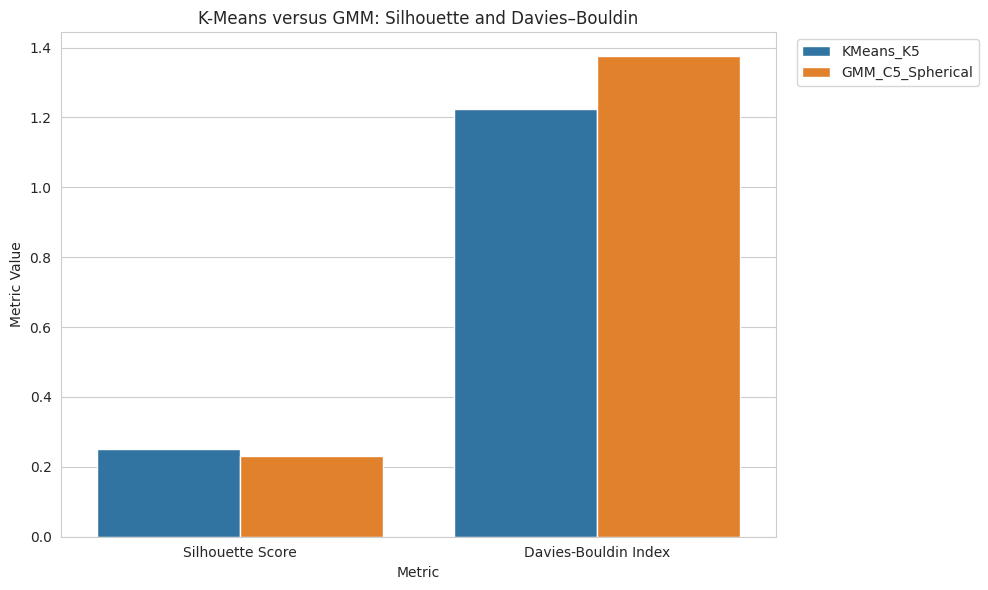

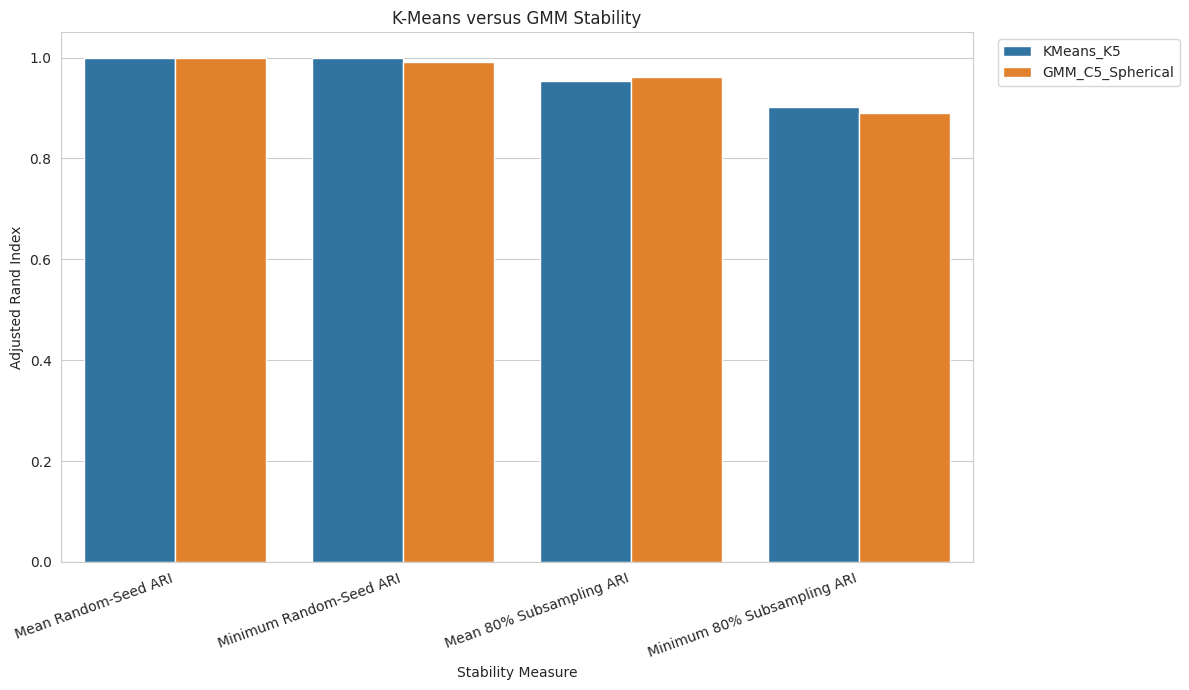

In [ ]:
common_validation_plot = (
    technical_comparison[
        technical_comparison[
            "Metric"
        ].isin(
            [
                "Silhouette Score",
                "Davies-Bouldin Index"
            ]
        )
    ]
    .melt(
        id_vars=[
            "Metric",
            "Preferred_Direction"
        ],
        value_vars=[
            "KMeans_K5",
            "GMM_C5_Spherical"
        ],
        var_name="Model",
        value_name="Value"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_validation_plot,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.title(
    "K-Means versus GMM: Silhouette and Davies–Bouldin"
)
plt.xlabel("Metric")
plt.ylabel("Metric Value")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_vs_gmm_silhouette_dbi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

stability_plot = (
    technical_comparison[
        technical_comparison[
            "Metric"
        ].isin(
            [
                "Mean Random-Seed ARI",
                "Minimum Random-Seed ARI",
                "Mean 80% Subsampling ARI",
                "Minimum 80% Subsampling ARI"
            ]
        )
    ]
    .melt(
        id_vars="Metric",
        value_vars=[
            "KMeans_K5",
            "GMM_C5_Spherical"
        ],
        var_name="Model",
        value_name="ARI"
    )
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stability_plot,
    x="Metric",
    y="ARI",
    hue="Model"
)

plt.title(
    "K-Means versus GMM Stability"
)
plt.xlabel("Stability Measure")
plt.ylabel("Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.xticks(
    rotation=20,
    ha="right"
)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_vs_gmm_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

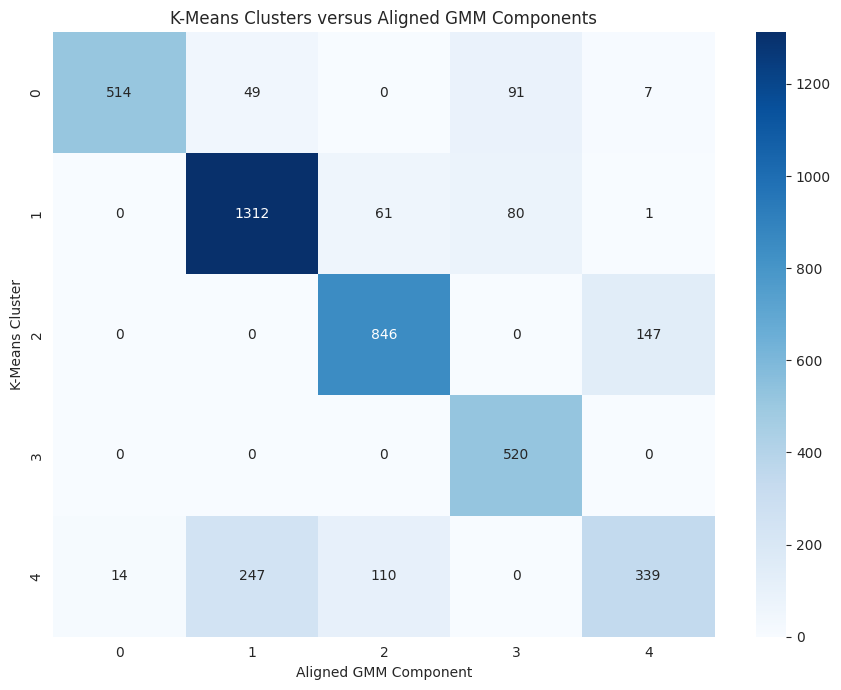

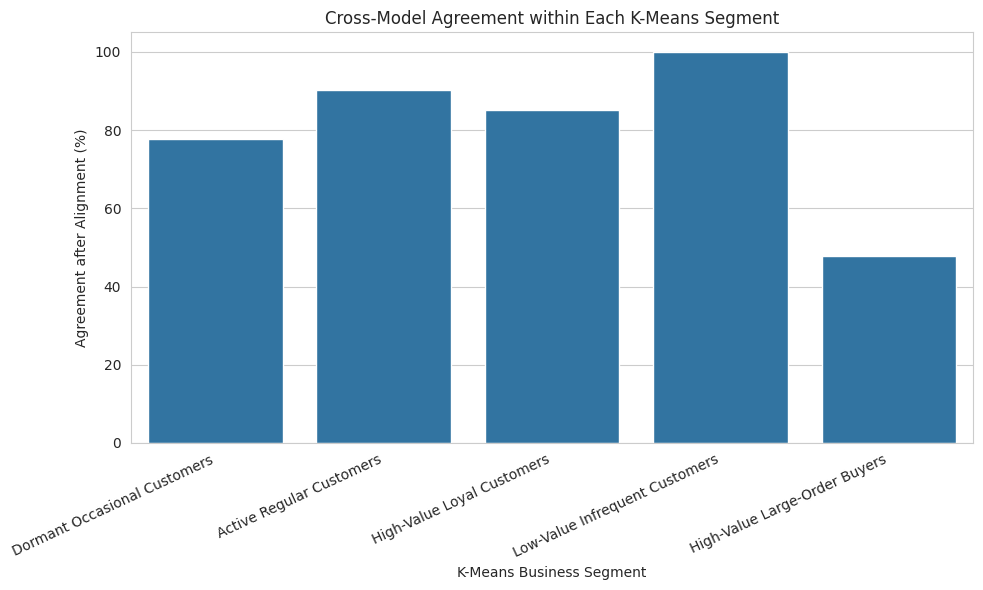

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    aligned_assignment_matrix.iloc[
        :-1,
        :-1
    ],
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "K-Means Clusters versus Aligned GMM Components"
)
plt.xlabel("Aligned GMM Component")
plt.ylabel("K-Means Cluster")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "kmeans_vs_aligned_gmm_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=movement_summary,
    x="KMeans_Segment",
    y="Agreement_Percentage"
)

plt.title(
    "Cross-Model Agreement within Each K-Means Segment"
)
plt.xlabel("K-Means Business Segment")
plt.ylabel("Agreement after Alignment (%)")
plt.xticks(
    rotation=25,
    ha="right"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "cross_model_agreement_by_kmeans_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

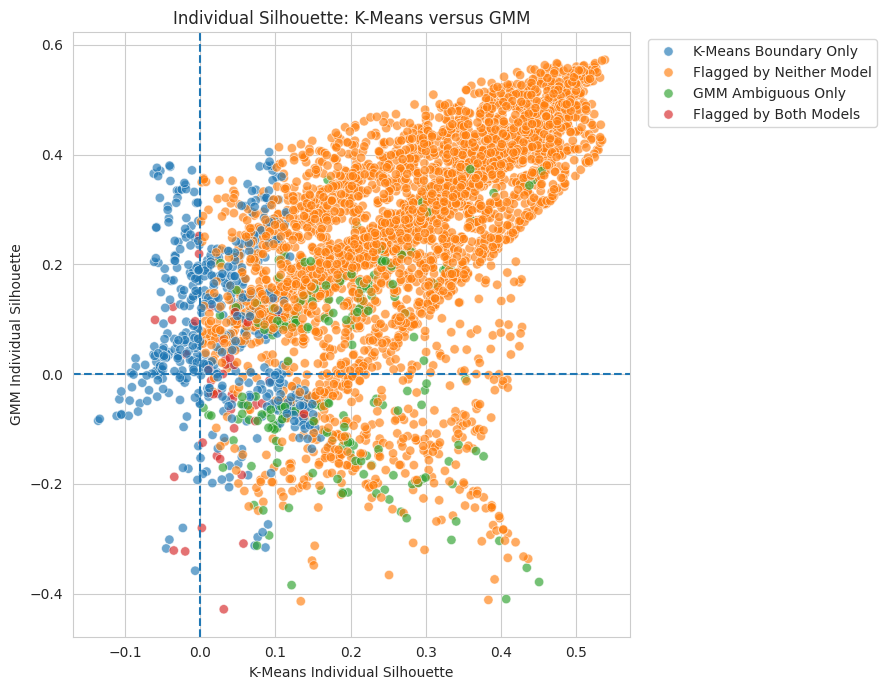

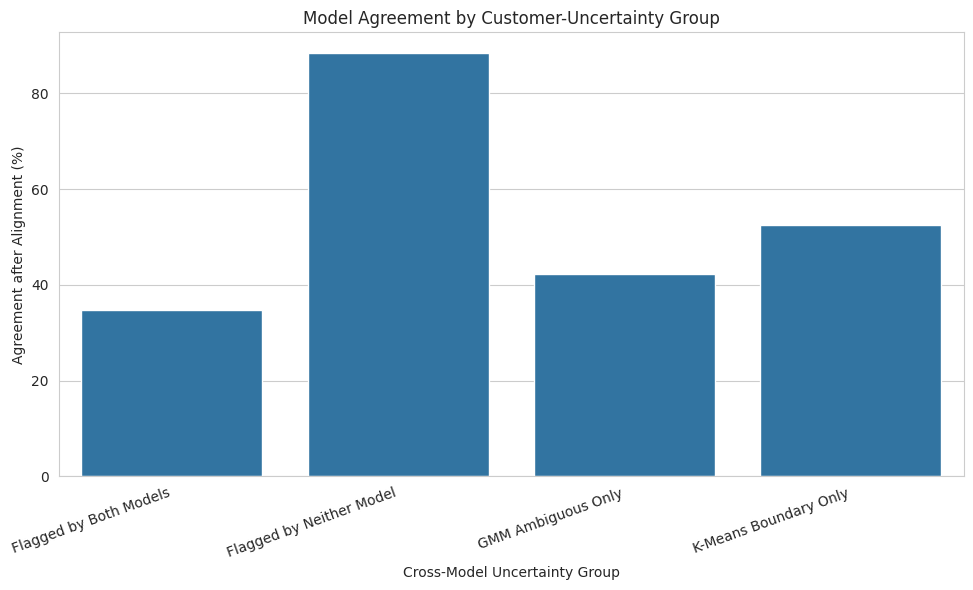

In [ ]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=customer_model_comparison,
    x="Silhouette_Value_KMeans",
    y="Silhouette_Value_GMM",
    hue="Cross_Model_Uncertainty_Group",
    alpha=0.65,
    s=45
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Individual Silhouette: K-Means versus GMM"
)
plt.xlabel("K-Means Individual Silhouette")
plt.ylabel("GMM Individual Silhouette")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "individual_silhouette_cross_model_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=agreement_by_cross_uncertainty,
    x="Cross_Model_Uncertainty_Group",
    y="Models_Agree_Percentage"
)

plt.title(
    "Model Agreement by Customer-Uncertainty Group"
)
plt.xlabel("Cross-Model Uncertainty Group")
plt.ylabel("Agreement after Alignment (%)")
plt.xticks(
    rotation=20,
    ha="right"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "model_agreement_by_uncertainty_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Export the dashboard-ready comparison dataset

In [ ]:
customer_model_comparison.to_csv(
    DATASETS_DIR
    / "kmeans_vs_gmm_customer_comparison.csv",
    index=False
)

disagreement_customers = (
    customer_model_comparison[
        ~customer_model_comparison[
            "Models_Agree_After_Alignment"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Cross_Model_Uncertainty_Group",
            "CustomerID"
        ]
    )
    .reset_index(drop=True)
)

disagreement_customers.to_csv(
    DATASETS_DIR
    / "kmeans_vs_gmm_disagreement_customers.csv",
    index=False
)

both_uncertain_customers = (
    customer_model_comparison[
        customer_model_comparison[
            "Cross_Model_Uncertainty_Group"
        ] == "Flagged by Both Models"
    ]
    .copy()
    .reset_index(drop=True)
)

both_uncertain_customers.to_csv(
    DATASETS_DIR
    / "customers_flagged_uncertain_by_both_models.csv",
    index=False
)

print("Customer-level comparison datasets exported.")

Customer-level comparison datasets exported.


## 18. Run final comparison quality checks

In [ ]:
assert len(
    customer_model_comparison
) == EXPECTED_CUSTOMERS

assert customer_model_comparison[
    "CustomerID"
].is_unique

assert (
    customer_model_comparison[
        "Cluster"
    ].nunique()
    == EXPECTED_GROUPS
)

assert (
    customer_model_comparison[
        "GMM_Component"
    ].nunique()
    == EXPECTED_GROUPS
)

assert set(
    gmm_to_kmeans_mapping.keys()
) == set(
    range(EXPECTED_GROUPS)
)

assert set(
    gmm_to_kmeans_mapping.values()
) == set(
    range(EXPECTED_GROUPS)
)

assert (
    confidence_overlap_summary[
        "Customer_Count"
    ].iloc[
        0:4
    ].sum()
    == EXPECTED_CUSTOMERS
)

assert (
    negative_silhouette_comparison[
        "Customer_Count"
    ].sum()
    == EXPECTED_CUSTOMERS
)

assert agreement_summary[
    "Value"
].between(
    0,
    1,
    inclusive="both"
).all()

assert alignment_summary[
    "Value"
].between(
    0,
    1,
    inclusive="both"
).all()

required_outputs = [
    TABLES_DIR
    / "kmeans_vs_gmm_common_technical_metrics.csv",
    TABLES_DIR
    / "kmeans_vs_gmm_assignment_agreement.csv",
    TABLES_DIR
    / "kmeans_vs_gmm_confidence_overlap_summary.csv",
    TABLES_DIR
    / "individual_silhouette_relationship_summary.csv",
    ALIGNMENT_DIR
    / "gmm_to_kmeans_overlap_alignment.csv",
    ALIGNMENT_DIR
    / "kmeans_vs_aligned_gmm_assignment_matrix.csv",
    DATASETS_DIR
    / "kmeans_vs_gmm_customer_comparison.csv",
    DATASETS_DIR
    / "kmeans_vs_gmm_disagreement_customers.csv"
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing comparison outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

quality_checks = pd.DataFrame({
    "Quality_Check": [
        "Customer population remains 4,338",
        "CustomerID values are unique",
        "K-Means contains five groups",
        "GMM contains five groups",
        "Alignment maps every GMM component once",
        "Alignment maps to every K-Means cluster once",
        "Confidence overlap categories sum to 4,338",
        "Negative-Silhouette categories sum to 4,338",
        "Unaligned agreement metrics are valid",
        "Aligned agreement metrics are valid",
        "Required comparison outputs created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_checks)

quality_checks.to_csv(
    QUALITY_DIR
    / "kmeans_vs_gmm_comparison_quality_checks.csv",
    index=False
)

print(
    "All K-Means versus GMM comparison checks passed."
)

,Quality_Check,Passed
0,"Customer population remains 4,338",True
1,CustomerID values are unique,True
2,K-Means contains five groups,True
3,GMM contains five groups,True
4,Alignment maps every GMM component once,True
5,Alignment maps to every K-Means cluster once,True
6,"Confidence overlap categories sum to 4,338",True
7,"Negative-Silhouette categories sum to 4,338",True
8,Unaligned agreement metrics are valid,True
9,Aligned agreement metrics are valid,True


All K-Means versus GMM comparison checks passed.


## 19. Create the Step 7 evidence summary

The summary reports technical and assignment evidence only.

The final model decision is deferred until Step 8 evaluates aligned
original-scale profiles, business distinctiveness and actionability.

In [ ]:
kmeans_boundary_percentage = float(
    kmeans_boundary_flag.mean()
    * 100
)

gmm_ambiguous_percentage = float(
    gmm_ambiguous_flag.mean()
    * 100
)

comparison_summary = {
    "models": [
        "K-Means K=5",
        "GMM C5 Spherical"
    ],
    "customers": EXPECTED_CUSTOMERS,
    "features": FEATURE_COLUMNS,
    "common_technical_metrics": {
        row["Metric"]: {
            "kmeans": float(
                row["KMeans_K5"]
            ),
            "gmm": float(
                row["GMM_C5_Spherical"]
            ),
            "metric_preference": (
                row["Metric_Preference"]
            )
        }
        for _, row in (
            technical_comparison.iterrows()
        )
    },
    "assignment_agreement": {
        "adjusted_rand_index": float(
            cross_model_ari
        ),
        "normalised_mutual_information": float(
            cross_model_nmi
        ),
        "exact_agreement_after_alignment": float(
            aligned_exact_agreement
        )
    },
    "confidence_evidence": {
        "kmeans_boundary_percentage": (
            kmeans_boundary_percentage
        ),
        "gmm_ambiguous_percentage": (
            gmm_ambiguous_percentage
        ),
        "customers_flagged_by_both": int(
            both_uncertain_flag.sum()
        ),
        "uncertainty_jaccard": float(
            uncertainty_jaccard
        ),
        "uncertainty_kappa": float(
            uncertainty_kappa
        )
    },
    "decision_status": (
        "No final model selected in Step 7."
    ),
    "next_step": (
        "Align and interpret original-scale model profiles, "
        "assign defensible GMM business names and evaluate "
        "business actionability."
    )
}

with open(
    RESULTS_DIR
    / "step7_kmeans_vs_gmm_comparison_summary.json",
    "w"
) as file:
    json.dump(
        comparison_summary,
        file,
        indent=4
    )

print(
    json.dumps(
        comparison_summary,
        indent=4
    )
)

{
    "models": [
        "K-Means K=5",
        "GMM C5 Spherical"
    ],
    "customers": 4338,
    "features": [
        "Recency",
        "Frequency",
        "Monetary",
        "AverageOrderValue",
        "BasketSize",
        "ProductDiversity",
        "TotalQuantity"
    ],
    "common_technical_metrics": {
        "Silhouette Score": {
            "kmeans": 0.251204,
            "gmm": 0.229893,
            "metric_preference": "K-Means K=5"
        },
        "Davies-Bouldin Index": {
            "kmeans": 1.223032,
            "gmm": 1.374938,
            "metric_preference": "K-Means K=5"
        },
        "Calinski-Harabasz Index": {
            "kmeans": 1755.968475,
            "gmm": 1587.495152,
            "metric_preference": "K-Means K=5"
        },
        "Mean Random-Seed ARI": {
            "kmeans": 0.999917,
            "gmm": 0.998484,
            "metric_preference": "K-Means K=5"
        },
        "Minimum Random-Seed ARI": {
            "kmeans": 0.99

## 20. Create the supervisor-ready comparison summary

In [ ]:
supervisor_summary = f'''
K-MEANS K=5 VERSUS GMM C5 SPHERICAL — STEP 7

Common analytical population
----------------------------
Customers: {EXPECTED_CUSTOMERS:,}
Features: {len(FEATURE_COLUMNS)}
Groups in each model: {EXPECTED_GROUPS}

Common internal validation
--------------------------
K-Means Silhouette:
{kmeans_row["Silhouette_Score"]:.4f}

GMM Silhouette:
{gmm_row["Silhouette_Score"]:.4f}

K-Means Davies-Bouldin:
{kmeans_row["Davies_Bouldin_Index"]:.4f}

GMM Davies-Bouldin:
{gmm_row["Davies_Bouldin_Index"]:.4f}

K-Means Calinski-Harabasz:
{kmeans_row["Calinski_Harabasz_Index"]:.2f}

GMM Calinski-Harabasz:
{gmm_row["Calinski_Harabasz_Index"]:.2f}

Stability
---------
K-Means mean random-seed ARI:
{kmeans_row["Mean_Random_Seed_ARI"]:.4f}

GMM mean random-seed ARI:
{gmm_row["Mean_Seed_ARI"]:.4f}

K-Means mean 80% subsampling ARI:
{kmeans_row["Mean_Subsampling_ARI"]:.4f}

GMM mean 80% subsampling ARI:
{gmm_row["Mean_Subsampling_ARI"]:.4f}

K-Means minimum 80% subsampling ARI:
{kmeans_row["Minimum_Subsampling_ARI"]:.4f}

GMM minimum 80% subsampling ARI:
{gmm_row["Minimum_Subsampling_ARI"]:.4f}

Assignment agreement
--------------------
ARI between models:
{cross_model_ari:.4f}

NMI between models:
{cross_model_nmi:.4f}

Exact agreement after overlap alignment:
{aligned_exact_agreement * 100:.2f}%

Customer-confidence evidence
----------------------------
K-Means combined boundary group:
{kmeans_boundary_flag.sum():,}
({kmeans_boundary_percentage:.2f}%)

GMM combined ambiguous group:
{gmm_ambiguous_flag.sum():,}
({gmm_ambiguous_percentage:.2f}%)

Flagged by both models:
{both_uncertain_flag.sum():,}
({both_uncertain_flag.mean() * 100:.2f}%)

Important interpretation
------------------------
K-Means produced stronger common internal validation.
Both models demonstrated strong stability, with GMM showing a
slightly higher mean subsampling ARI and K-Means showing a
slightly stronger worst-case subsampling result.

Customer-confidence rates are descriptive and are not directly
equivalent because the models use different uncertainty measures.

No final operational model is selected in Step 7.
The next stage aligns and interprets the original-scale profiles,
assigns defensible GMM business names and evaluates actionability.
'''.strip()

with open(
    RESULTS_DIR
    / "supervisor_kmeans_vs_gmm_step7_summary.txt",
    "w"
) as file:
    file.write(
        supervisor_summary
    )

print(supervisor_summary)

K-MEANS K=5 VERSUS GMM C5 SPHERICAL — STEP 7

Common analytical population
----------------------------
Customers: 4,338
Features: 7
Groups in each model: 5

Common internal validation
--------------------------
K-Means Silhouette:
0.2512

GMM Silhouette:
0.2299

K-Means Davies-Bouldin:
1.2230

GMM Davies-Bouldin:
1.3749

K-Means Calinski-Harabasz:
1755.97

GMM Calinski-Harabasz:
1587.50

Stability
---------
K-Means mean random-seed ARI:
0.9999

GMM mean random-seed ARI:
0.9985

K-Means mean 80% subsampling ARI:
0.9541

GMM mean 80% subsampling ARI:
0.9610

K-Means minimum 80% subsampling ARI:
0.9011

GMM minimum 80% subsampling ARI:
0.8898

Assignment agreement
--------------------
ARI between models:
0.6289

NMI between models:
0.6512

Exact agreement after overlap alignment:
81.40%

Customer-confidence evidence
----------------------------
K-Means combined boundary group:
541
(12.47%)

GMM combined ambiguous group:
259
(5.97%)

Flagged by both models:
46
(1.06%)

Important interpret

## 21. Save the comparison methodology manifest

In [ ]:
comparison_manifest = {
    "purpose": (
        "Compare frozen K-Means K=5 and frozen "
        "GMM C5 spherical outputs without retraining."
    ),
    "customers": EXPECTED_CUSTOMERS,
    "features": FEATURE_COLUMNS,
    "models": {
        "kmeans": {
            "configuration": "K-Means K=5",
            "frozen": True
        },
        "gmm": {
            "configuration": "GMM C5 spherical",
            "frozen": True
        }
    },
    "common_comparison_evidence": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "random-seed ARI",
        "80% subsampling ARI",
        "smallest group percentage"
    ],
    "assignment_comparison": {
        "unlabelled_partition_metrics": [
            "Adjusted Rand Index",
            "Normalised Mutual Information"
        ],
        "alignment_method": (
            "Hungarian maximum-overlap one-to-one mapping"
        ),
        "alignment_limitation": (
            "Maximum customer overlap does not by itself "
            "prove identical business meaning."
        )
    },
    "confidence_comparison_limitation": (
        "K-Means and GMM uncertainty conditions are "
        "descriptive but not directly equivalent."
    ),
    "final_model_selected": False,
    "next_step": (
        "Aligned original-scale profile interpretation "
        "and business actionability comparison."
    )
}

with open(
    RESULTS_DIR
    / "step7_comparison_methodology_manifest.json",
    "w"
) as file:
    json.dump(
        comparison_manifest,
        file,
        indent=4
    )

print(
    "Comparison methodology manifest saved."
)

Comparison methodology manifest saved.


## 22. Create the final Step 7 results ZIP

In [ ]:
zip_path = shutil.make_archive(
    base_name=(
        "/content/"
        "KMeans_K5_vs_GMM_C5_Comparison_Results"
    ),
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("STEP 7 MODEL COMPARISON COMPLETED")
print("=" * 80)

print("\nResults folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nKey outputs:")
print("1. kmeans_vs_gmm_common_technical_metrics.csv")
print("2. kmeans_vs_gmm_assignment_agreement.csv")
print("3. gmm_to_kmeans_overlap_alignment.csv")
print("4. kmeans_vs_aligned_gmm_assignment_matrix.csv")
print("5. segment_level_model_agreement_summary.csv")
print("6. kmeans_vs_gmm_confidence_overlap_summary.csv")
print("7. individual_silhouette_relationship_summary.csv")
print("8. kmeans_vs_gmm_customer_comparison.csv")
print("9. kmeans_vs_gmm_disagreement_customers.csv")
print("10. supervisor_kmeans_vs_gmm_step7_summary.txt")

STEP 7 MODEL COMPARISON COMPLETED

Results folder:
/content/KMeans_K5_vs_GMM_C5_Comparison_Results

ZIP archive:
/content/KMeans_K5_vs_GMM_C5_Comparison_Results.zip

Key outputs:
1. kmeans_vs_gmm_common_technical_metrics.csv
2. kmeans_vs_gmm_assignment_agreement.csv
3. gmm_to_kmeans_overlap_alignment.csv
4. kmeans_vs_aligned_gmm_assignment_matrix.csv
5. segment_level_model_agreement_summary.csv
6. kmeans_vs_gmm_confidence_overlap_summary.csv
7. individual_silhouette_relationship_summary.csv
8. kmeans_vs_gmm_customer_comparison.csv
9. kmeans_vs_gmm_disagreement_customers.csv
10. supervisor_kmeans_vs_gmm_step7_summary.txt
